# Segmentation Pipeline Report

This notebook illustrates the image segmentation stage of the UNO vision pipeline. The goal of this stage is not to classify cards directly, but to isolate clean binary patches of the visible card symbols and keep enough metadata to classify and place them later.

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from segmentation import segmentation_utils as seg
from notebook_utils import overlay_mask, show_image, show_masks

BASE_DIR = Path(seg.BASE_DIR)
TEST_DIR = seg.TEST_DIR

DEMO_IMAGE_PATHS = [
    TEST_DIR / "L1001024.jpg",  # colorful background, yellow token
    TEST_DIR / "L1000896.jpg",  # white background, grey token
]

demo_images = [Image.open(path).convert("RGB") for path in DEMO_IMAGE_PATHS]
IMAGE_PATH = DEMO_IMAGE_PATHS[0]
img_color = demo_images[0]



## Input Images

The dataset contains two visual setups. Some images are taken on a colorful table background with a yellow circular active-player token, while others are taken on a white background with a grey rectangular token. The token is important for the final pipeline because it identifies the active player, but it also interferes with color segmentation if it is not handled explicitly.

We display one example of each setup here to verify that the pipeline recognizes both cases. The rest of the notebook then continues with the first image, which keeps the intermediate visualizations easy to compare from one stage to the next.



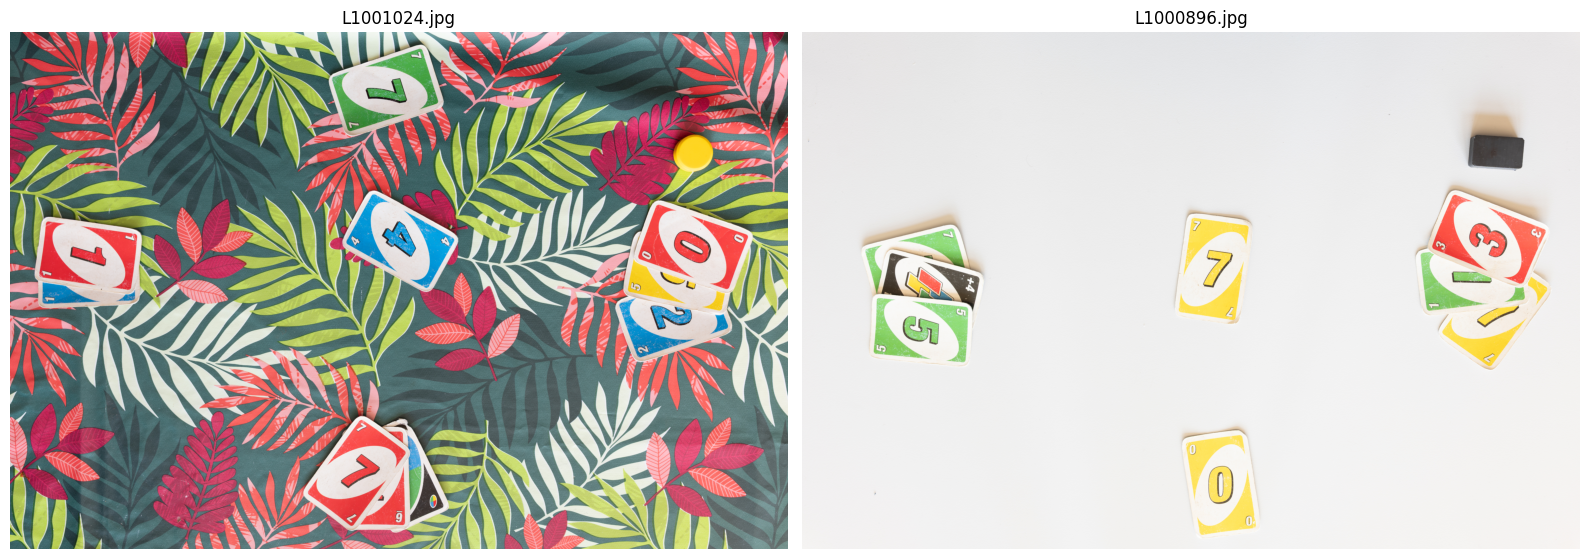

In [2]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    show_image(image, path.name, ax=ax)

plt.tight_layout()


## Image Type And Token Center

The first decision is which type of active-player token is present. `image_token_type` uses the average image brightness as a simple cue: white-background images are much brighter overall and use the grey token, while colorful-background images are darker overall and use the yellow token.

`get_token_center` then uses a different localization method for each token type. For the yellow token, the pipeline thresholds yellow pixels and looks for a circular component with `find_circle_hough`, because the token is approximately round. For the grey token, the pipeline thresholds the grey HSV range, keeps the largest connected component with `biggest_object`, and returns its centroid with `mask_center`.



L1001024.jpg: detected token type = yellow; token center = (3521, 625)
L1000896.jpg: detected token type = grey; token center = (3570, 622)


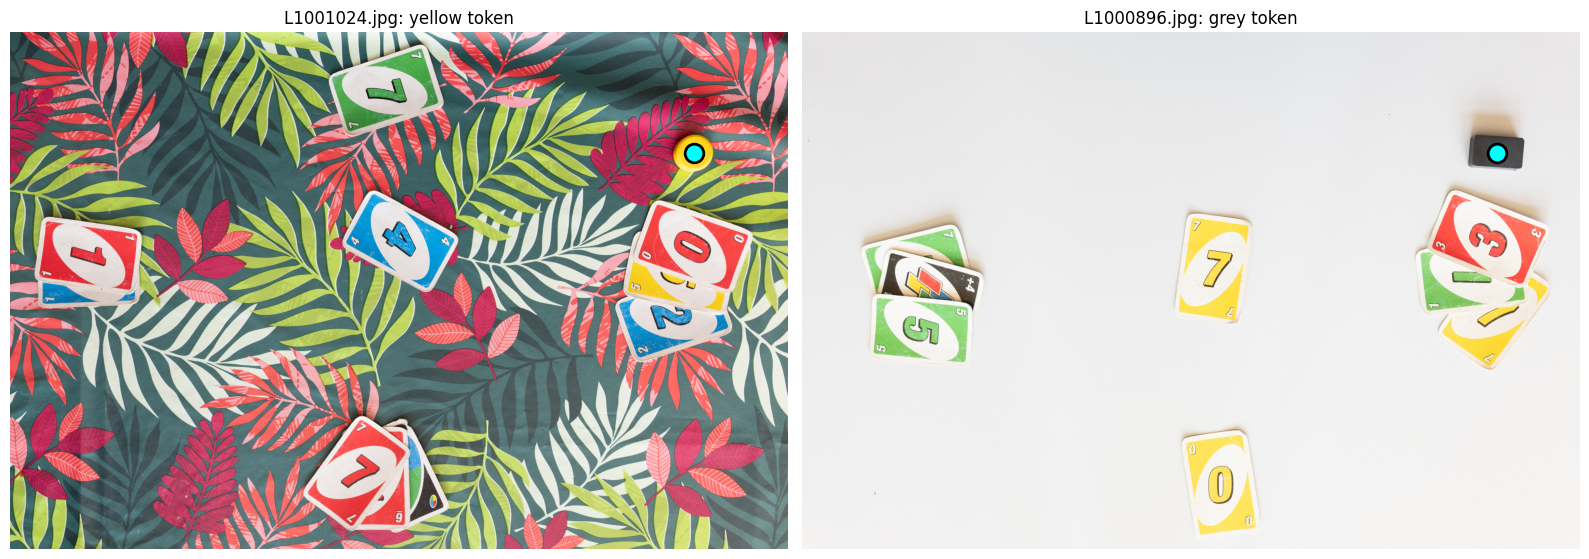

In [3]:
fig, axes = plt.subplots(1, len(demo_images), figsize=(8 * len(demo_images), 6))
axes = np.atleast_1d(axes)

for ax, path, image in zip(axes, DEMO_IMAGE_PATHS, demo_images):
    token = seg.image_token_type(image)
    token_center = seg.get_token_center(image)
    print(f"{path.name}: detected token type = {token}; token center = {token_center}")

    show_image(image, f"{path.name}: {token} token", ax=ax)
    if token_center is not None:
        ax.scatter(*token_center, s=180, c="cyan", edgecolors="black", linewidths=2)

plt.tight_layout()


For the rest of the pipeline demonstration we focus on the first image. This avoids mixing intermediate masks from different scenes and makes it easier to see how each processing step transforms the same input.



## Color Masks

The pipeline starts by separating the image into one binary mask per UNO color: blue, green, red, yellow, black, and white. We decided to do this to exploit the color design of the cards. `get_color_masks` loads the HSV ranges from `hsv_thresholds/`, applies `cv2.inRange` for each configured range, and combines the ranges belonging to the same color. Each of the hsv thresholds defined by the .txt files in the `hsv_thresholds/` were chosen manually on a sample of training images using the `hsv_tuner.py` tool.

HSV is used instead of raw RGB because hue and saturation are more stable under changes in brightness, and allow for easier segmentation of the different colors. After thresholding, each mask is morphologically closed with `morph_close` to fill small gaps, then passed through `min_area_filter` so small components are removed.



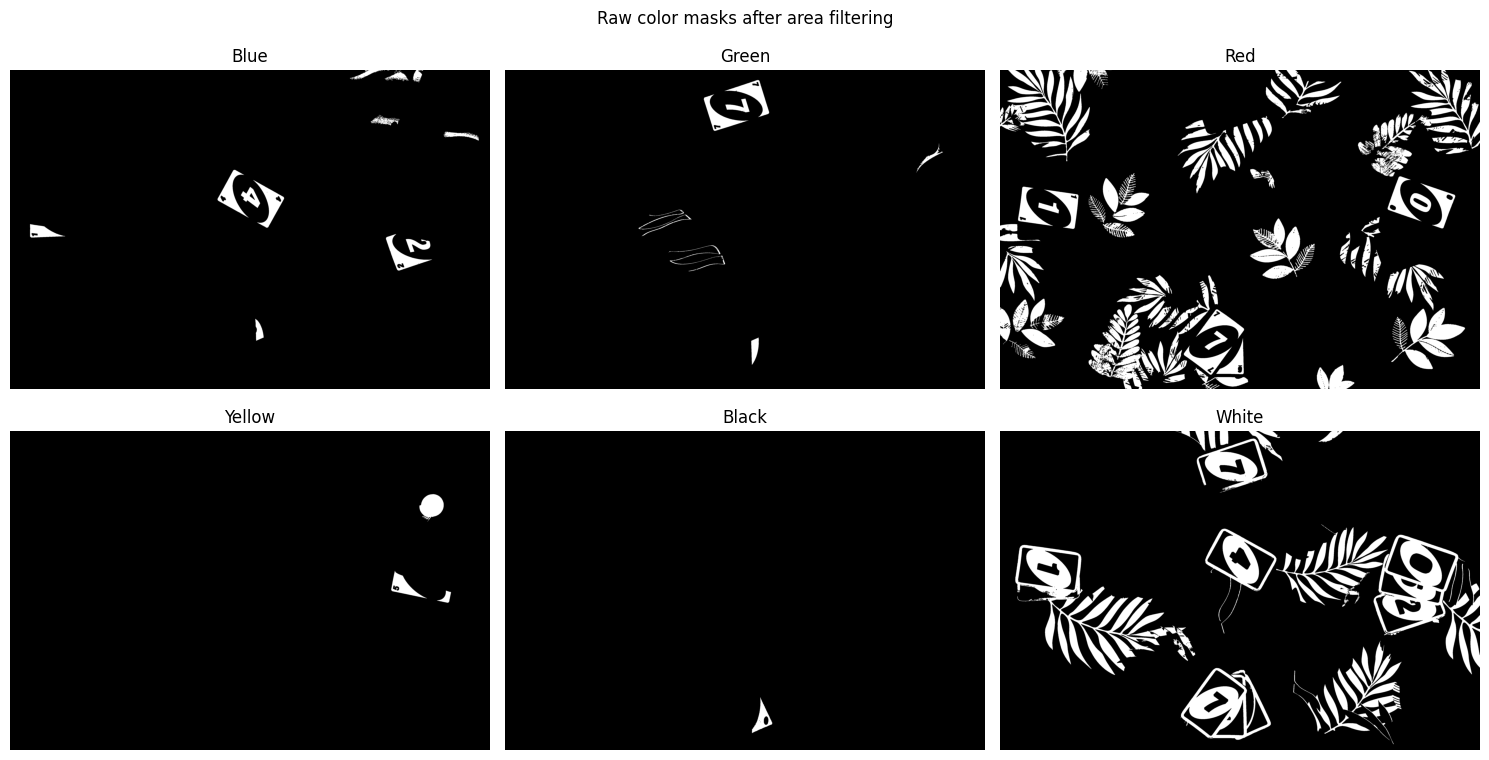

In [4]:
color_masks = seg.get_color_masks(img_color)
show_masks(color_masks, title="Raw color masks after area filtering")


At this point in the pipeline, we can see some card parts as well as a lot of noisy elements, especially from the background. The next steps will focus on refining this segmentation of cards.

## Token Removal

The active-player token can have the same color as objects we care about. On colorful backgrounds the token is yellow, so it may be mistaken for a yellow card region. On white-background images the grey token can overlap with the black mask.

`remove_token_from_color_masks` solves this problem by forcing to 0 pixels from the yellow/black masks, if their coordinates correspond to coordinates of token pixels. 


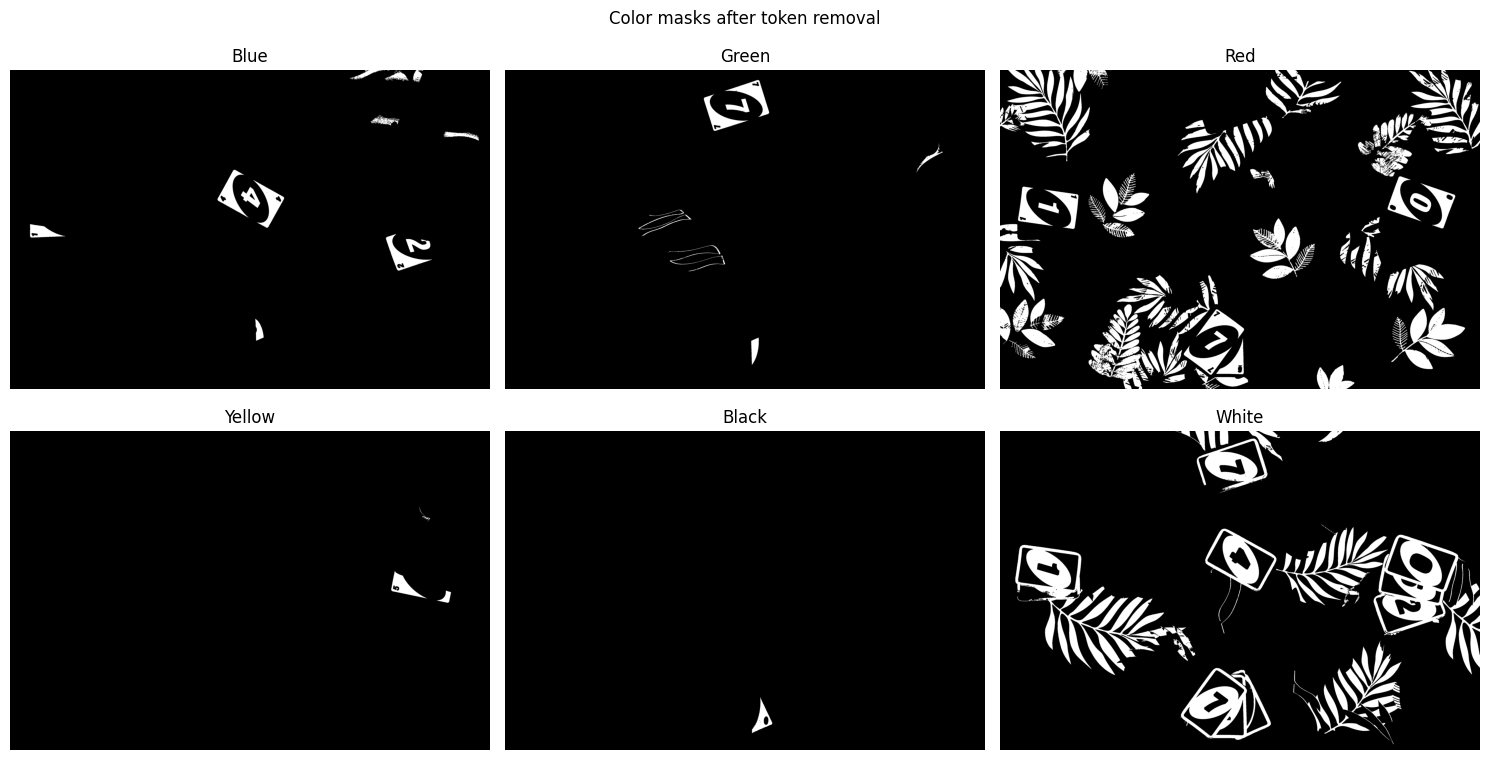

In [5]:
token_removed_masks = seg.remove_token_from_color_masks(
    img_color,
    {color: mask.copy() for color, mask in color_masks.items()},
)
show_masks(token_removed_masks, title="Color masks after token removal")


We can see that the yellow token that previously appeared in the yellow mask has been suppressed and can no longer be mistaken for a card in the rest of the pipeline.

## Keep Card-Like Objects

After color thresholding, a mask may still contain non-card objects: table artifacts, shadows, parts of the token that survived the previous step, or noise that survived the area filter. The UNO cards in these images have a useful structural property: colored card interiors are surrounded by a white border.

`keep_white_surrounded_objects` uses that property to keep only colored components that look card-like. For each connected component, `keep_objects_surrounded_by_white` builds a ring around the object by dilating it and subtracting the original object. It then measures how much of that ring overlaps the white mask. Components with enough surrounding white are retained; the others are discarded. This is a geometric sanity check layered on top of color thresholding.



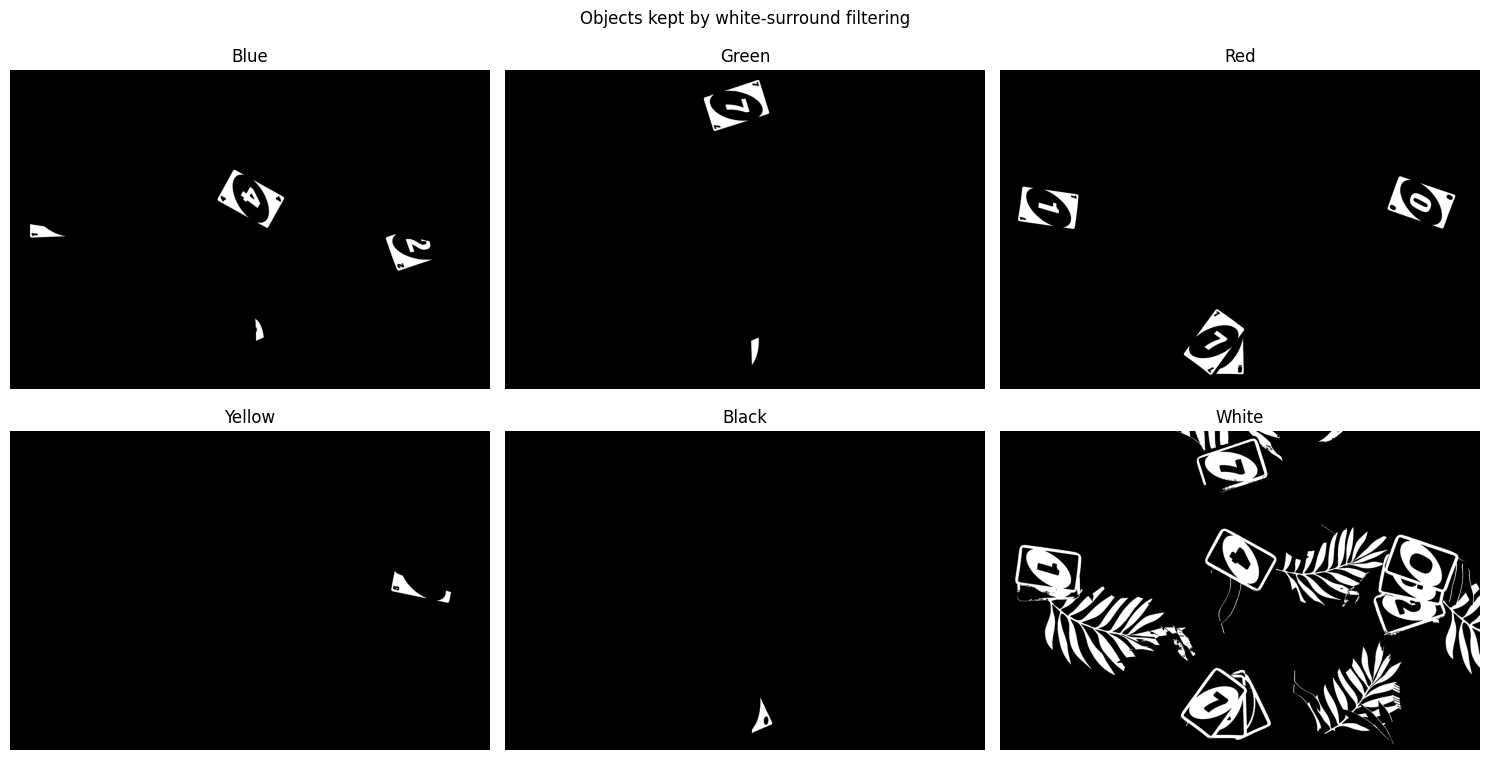

In [6]:
card_masks = seg.keep_white_surrounded_objects(
    {color: mask.copy() for color, mask in token_removed_masks.items()}
)
show_masks(card_masks, title="Objects kept by white-surround filtering")


## Holes Inside Card Shapes

Once card-like colored regions are isolated, the next idea is to look for holes inside them. In a binary card mask, white printed symbols appear as missing pixels inside the colored region. `get_holes` fills the exterior background, finds enclosed empty regions, and returns those enclosed regions as candidate symbol pixels.

This step is useful because it turns the symbol search into a shape problem: instead of detecting every possible card symbol directly in RGB space, we first ask which white regions are enclosed by colored cards. The visualization below shows all such enclosed regions before the stricter filtering is applied.



<Axes: title={'center': 'All holes inside colored card regions'}>

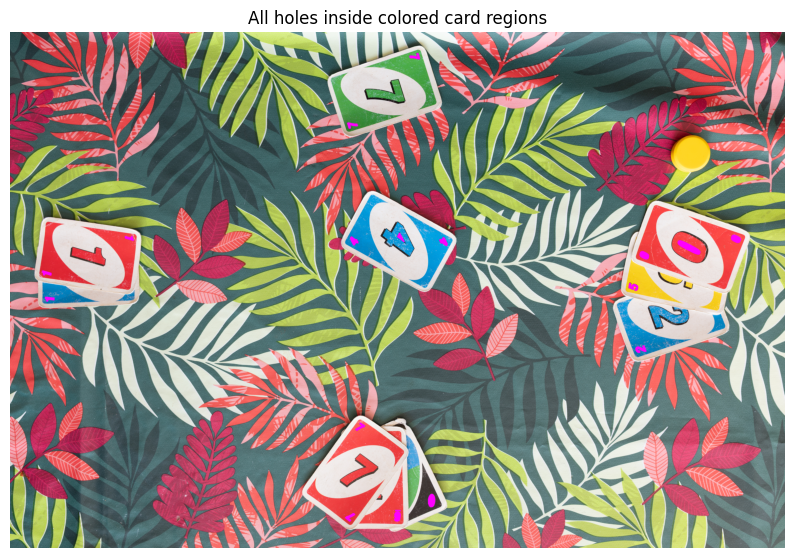

In [7]:
hole_masks = {
    color: seg.get_holes(mask, min_hole_area=100)
    for color, mask in card_masks.items()
    if color != "white"
}
all_holes = np.bitwise_or.reduce(list(hole_masks.values()))
overlay_mask(img_color, all_holes, title="All holes inside colored card regions")


This raw hole-based method is intentionally over-inclusive. Some center symbols contain internal holes themselves, such as `0`, `4`, `6`, `8`, `9`, skip, and `+4`. Those inner holes are not corner symbols, but they are still enclosed by colored pixels, so they appear as candidates.

The next stage filters these candidates using card layout. Corner symbols sit near the white card border, while holes inside the large center symbol remain farther from that border. That spatial difference is what lets us reject many false candidates without needing a classifier yet.



## Filtered Symbol Masks

`extract_symbols_mask_per_color` applies the full symbol-candidate filtering strategy. It starts from the holes found inside each colored card mask, then keeps candidates that are plausible corner symbols.

The key helper is `filter_shapes_by_dilated_ring_overlap_binary`. For each candidate shape, the function dilates the shape and inspects only the newly added ring around it. If that ring overlaps enough white border pixels, the candidate is kept. This works because corner symbols are close enough to the card border for their dilation ring to touch white, while false holes inside the central symbol usually stay trapped inside the colored/central-symbol area.

The function also intersects candidates with `white_by_hsv`, a low-saturation mask, to prefer white or near-white symbol pixels and reject colorful artifacts. The result is one cleaned symbol mask per card color.



<Axes: title={'center': 'Final symbol pixels overlaid on the input'}>

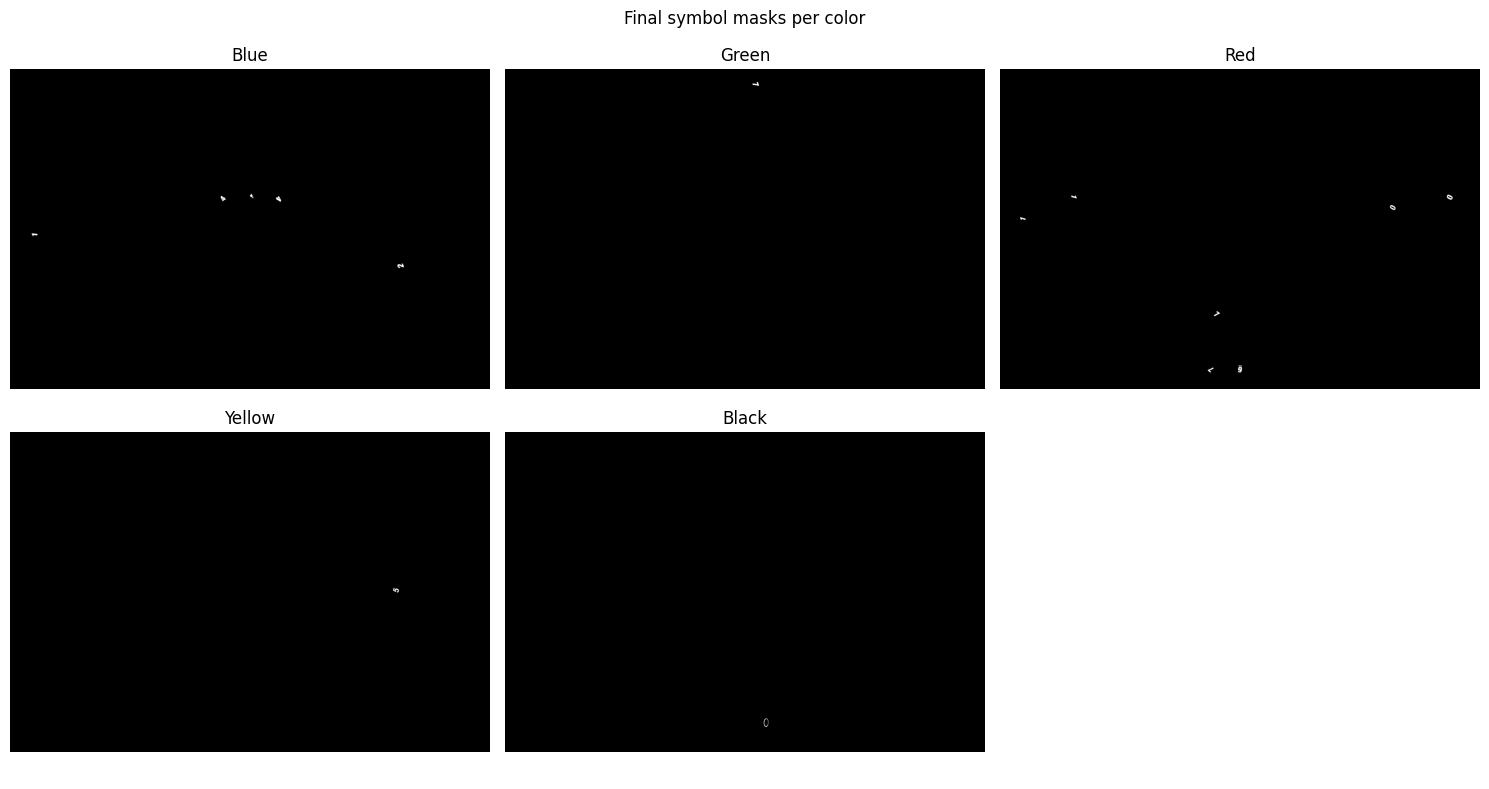

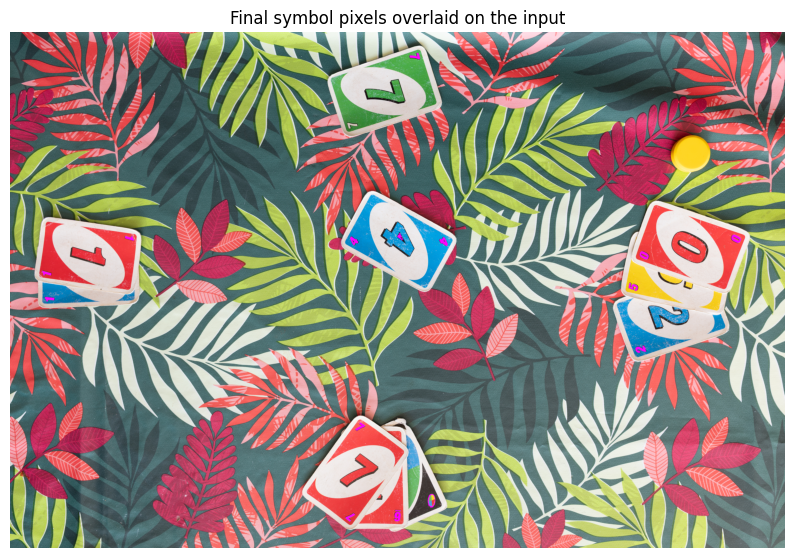

In [8]:
symbols_mask_per_color = seg.extract_symbols_mask_per_color(img_color, card_masks)
total_symbol_mask = np.bitwise_or.reduce(list(symbols_mask_per_color.values()))

show_masks(symbols_mask_per_color, columns=3, title="Final symbol masks per color")
overlay_mask(img_color, total_symbol_mask, title="Final symbol pixels overlaid on the input")


## Extracted Symbol Patches

The final segmentation output must be usable by the CNN classifier. `detect_symbols` therefore wraps all previous steps and converts the final symbol masks into individual records.

Inside it, `extract_merged_symbol_records` merges nearby foreground pixels that belong to the same printed symbol, computes each symbol center in the original image, and calls `crop_centered_binary_mask` to create a fixed-size binary patch around the symbol. Each returned record contains the patch, the card color, and the image-space center. The classifier later predicts the symbol label from the patch, while the color and center are used to reconstruct the card and assign it to a player or the table.



Detected symbols: 15


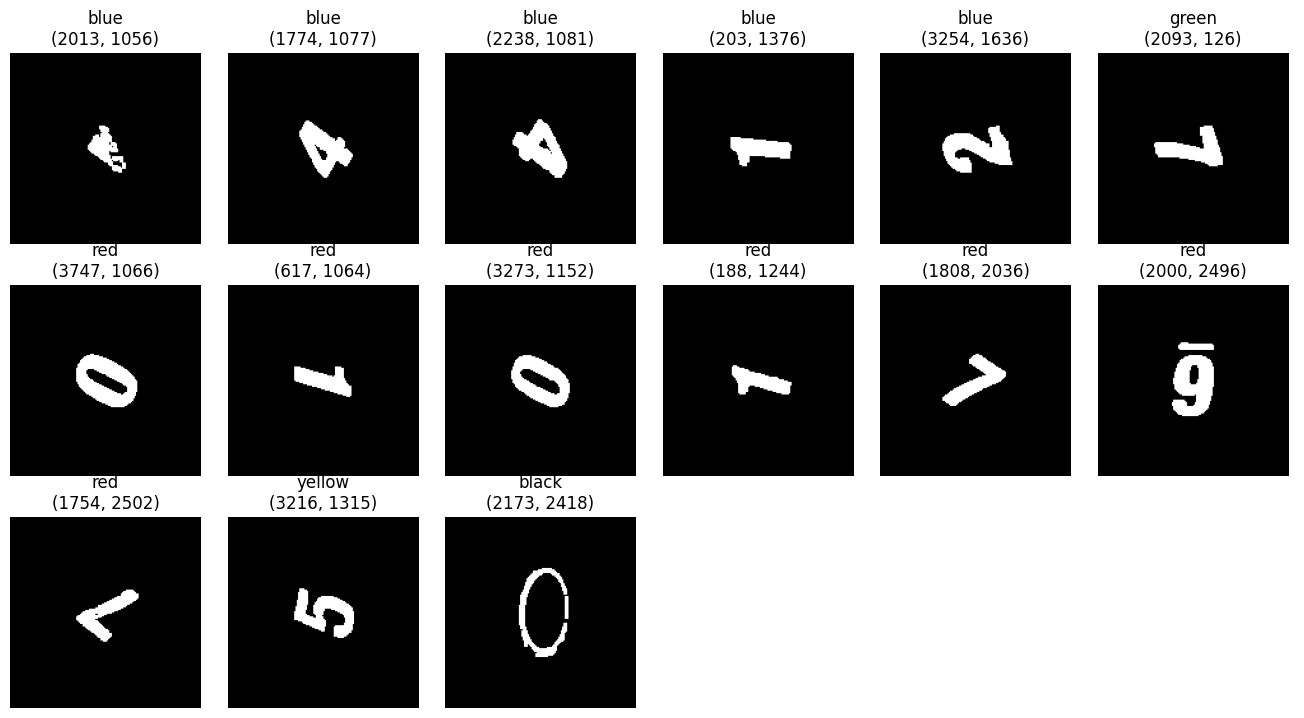

In [9]:
detected_symbols = seg.detect_symbols(img_color)
print(f"Detected symbols: {len(detected_symbols)}")

columns = min(6, max(1, len(detected_symbols)))
rows = int(np.ceil(len(detected_symbols) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(2.2 * columns, 2.4 * rows))
axes = np.atleast_1d(axes).ravel()

for ax, (patch, color, center_xy) in zip(axes, detected_symbols):
    ax.imshow(patch, cmap="gray")
    ax.set_title(f"{color}\n({center_xy[0]:.0f}, {center_xy[1]:.0f})")
    ax.axis("off")

for ax in axes[len(detected_symbols):]:
    ax.axis("off")

plt.tight_layout()
